In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pylab as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import numpy as np



In [22]:
df = pd.read_csv("Final_Project_CSV.csv")
df.head()

,CustomerID,Age,Family,Experience,Income,CCAvg,Mortgage,EducGrad,EducProf,Securities,CD,Online,CreditCard,PersonalLoan
0,1,25,4,1,49,1.6,0,0,0,1,0,0,0,0
1,2,45,3,19,34,1.5,0,0,0,1,0,0,0,0
2,3,39,1,15,11,1.0,0,0,0,0,0,0,0,0
3,4,35,1,9,100,2.7,0,1,0,0,0,0,0,0
4,5,35,4,8,45,1.0,0,1,0,0,0,0,1,0


In [23]:
y = df['PersonalLoan']
x = df[['Age','Family','Experience','Income','CCAvg','Mortgage',
        'EducGrad','EducProf','Securities','CD','Online','CreditCard']]

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.50 , random_state=101)

In [25]:
x_train_sm = sm.add_constant(x_train)

logit_model = sm.Logit(y_train, x_train_sm).fit()
logit_model.summary()

Optimization terminated successfully.
         Current function value: 0.120869
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           PersonalLoan   No. Observations:                 2500
Model:                          Logit   Df Residuals:                     2487
Method:                           MLE   Df Model:                           12
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                  0.6231
Time:                        18:16:19   Log-Likelihood:                -302.17
converged:                       True   LL-Null:                       -801.67
Covariance Type:            nonrobust   LLR p-value:                3.096e-206
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -12.3165      2.471     -4.984      0.000     -17.160      -7.473
Age           -0.0043      0.091     -0.047      0.963      -0.183       0.174
Family         0.5738      0.107      5.344      0.000       0.363       0.784
Experience     0.0120      0.091      0.132      0.895      -0.166       0.190
Income         0.0551      0.004     14.261      0.000       0.047       0.063
CCAvg          0.1628      0.063      2.584      0.010       0.039       0.286
Mortgage       0.0011      0.001      1.358      0.174      -0.000       0.003
EducGrad       3.7819      0.367     10.296      0.000       3.062       4.502
EducProf       3.8637      0.366     10.557      0.000       3.146       4.581
Securities    -1.1780      0.453     -2.598      0.009      -2.067      -0.289
CD             4.1066      0.471      8.721      0.000       3.184       5.029
Online        -0.8403      0.232     -3.616      0.000      -1.296      -0.385
CreditCard    -0.8647      0.295     -2.935      0.003      -1.442      -0.287
==============================================================================
"""

In [26]:
pvals = logit_model.pvalues
pval_significance = dict()
for var, p in pvals.items():
    if p < 0.05:
        pval_significance[var] = "Significant"
    else:
        pval_significance[var] = "Not Significant"

for var, result in pval_significance.items():
    print(f"{var}: {result}")

const: Significant
Age: Not Significant
Family: Significant
Experience: Not Significant
Income: Significant
CCAvg: Significant
Mortgage: Not Significant
EducGrad: Significant
EducProf: Significant
Securities: Significant
CD: Significant
Online: Significant
CreditCard: Significant


In [27]:
#printing the coefficients of logistic regression
cols=x_train.columns

coef_lg=logit_model.params

coef_df = logit_model.params.to_frame(name="Coefficient")
coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient'])

print(coef_df.sort_values(by='Odds Ratio', ascending=False))

            Coefficient  Odds Ratio
CD             4.106609   60.740420
EducProf       3.863749   47.643649
EducGrad       3.781886   43.898776
Family         0.573753    1.774916
CCAvg          0.162803    1.176805
Income         0.055062    1.056606
Experience     0.012008    1.012080
Mortgage       0.001114    1.001115
Age           -0.004259    0.995751
Online        -0.840339    0.431564
CreditCard    -0.864727    0.421166
Securities    -1.178046    0.307880
const        -12.316524    0.000004


In [28]:
x_test_sm = sm.add_constant(x_test)

pred_prob = logit_model.predict(x_test_sm)
pred_class = (pred_prob >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred_class))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_class))
print(classification_report(y_test, pred_class))
print("AUC:", roc_auc_score(y_test, pred_prob))

Accuracy: 0.9576
Confusion Matrix:
 [[2249   16]
 [  90  145]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      2265
           1       0.90      0.62      0.73       235

    accuracy                           0.96      2500
   macro avg       0.93      0.80      0.85      2500
weighted avg       0.96      0.96      0.95      2500

AUC: 0.9641444741909727


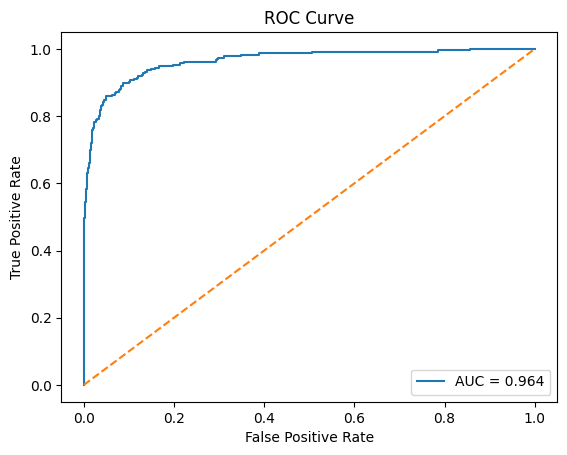

In [32]:
fpr, tpr, _ = roc_curve(y_test, pred_prob)
auc = roc_auc_score(y_test, pred_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')  # random model
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

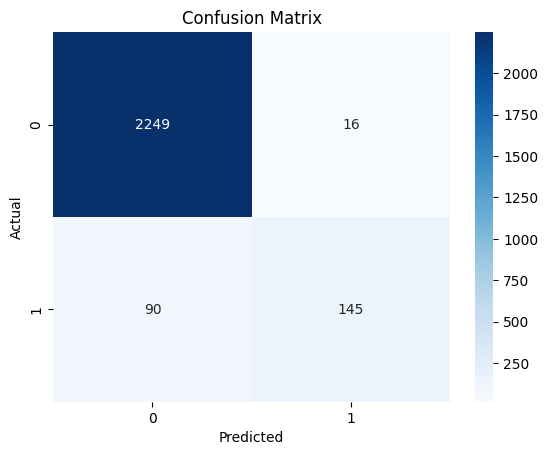

In [33]:
cm = confusion_matrix(y_test, pred_class)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()